## Bước 1: Khởi tạo môi trường và tải lên dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import files

# Lệnh kích hoạt nút bấm upload file từ máy tính của bạn
# Vui lòng tải lên file 'Middle_East_Economic_Data_1990_2024_with_Oil.csv'
uploaded = files.upload()

Saving Middle_East_Economic_Data_1990_2024_with_Oil.csv to Middle_East_Economic_Data_1990_2024_with_Oil.csv


## Bước 2: Đọc và khám phá dữ liệu ban đầu

In [2]:
file_name = 'Middle_East_Economic_Data_1990_2024_with_Oil.csv'
df = pd.read_csv(file_name)

print("--- ĐỌC FILE THÀNH CÔNG ---")
print(f"Kích thước dữ liệu: {df.shape[0]} hàng và {df.shape[1]} cột.\n")

print("Danh sách các cột trong file của bạn:")
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

df.head()

--- ĐỌC FILE THÀNH CÔNG ---
Kích thước dữ liệu: 455 hàng và 13 cột.

Danh sách các cột trong file của bạn:
1. Country
2. Country_Code
3. Year
4. Exports_pct_GDP
5. FDI_net_inflows_pct_GDP
6. GDP_current_USD
7. GDP_growth_annual_pct
8. GDP_per_capita_current_USD
9. Imports_pct_GDP
10. Inflation_consumer_prices_annual_pct
11. Life_expectancy_years
12. Unemployment_total_pct
13. Brent_Oil_Price_USD_per_barrel


,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0


## Bước 3: Làm sạch và tiền xử lý dữ liệu

In [3]:
print("--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH DỮ LIỆU ---")

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()
print(f"- Đã kiểm tra và xóa {duplicate_count} hàng bị trùng lặp.")

print("\n- Số lượng dòng bị khuyết (NaN) ở mỗi cột trước khi xử lý:")
print(df.isnull().sum())

columns_with_nan = ['Unemployment_total_pct', 'Exports_pct_GDP', 'FDI_net_inflows_pct_GDP',
                    'GDP_growth_annual_pct', 'Imports_pct_GDP', 'Inflation_consumer_prices_annual_pct']

for col in columns_with_nan:
    if col in df.columns and df[col].isnull().sum() > 0:
        mean_value = df[col].mean()
        df[col] = df[col].fillna(mean_value)

print("\n- Kiểm tra lại số lượng dòng khuyết sau khi xử lý:")
print(df.isnull().sum())
print(f"\nKích thước dữ liệu sạch cuối cùng: {df.shape[0]} hàng và {df.shape[1]} cột.")

--- BẮT ĐẦU QUÁ TRÌNH LÀM SẠCH DỮ LIỆU ---
- Đã kiểm tra và xóa 0 hàng bị trùng lặp.

- Số lượng dòng bị khuyết (NaN) ở mỗi cột trước khi xử lý:
Country                                  0
Country_Code                             0
Year                                     0
Exports_pct_GDP                         26
FDI_net_inflows_pct_GDP                  9
GDP_current_USD                          7
GDP_growth_annual_pct                    8
GDP_per_capita_current_USD               7
Imports_pct_GDP                         26
Inflation_consumer_prices_annual_pct    60
Life_expectancy_years                   13
Unemployment_total_pct                  14
Brent_Oil_Price_USD_per_barrel           0
dtype: int64

- Kiểm tra lại số lượng dòng khuyết sau khi xử lý:
Country                                  0
Country_Code                             0
Year                                     0
Exports_pct_GDP                          0
FDI_net_inflows_pct_GDP                  0
GDP_current_USD 

### Câu hỏi 1: Xu hướng giá dầu Brent toàn cầu

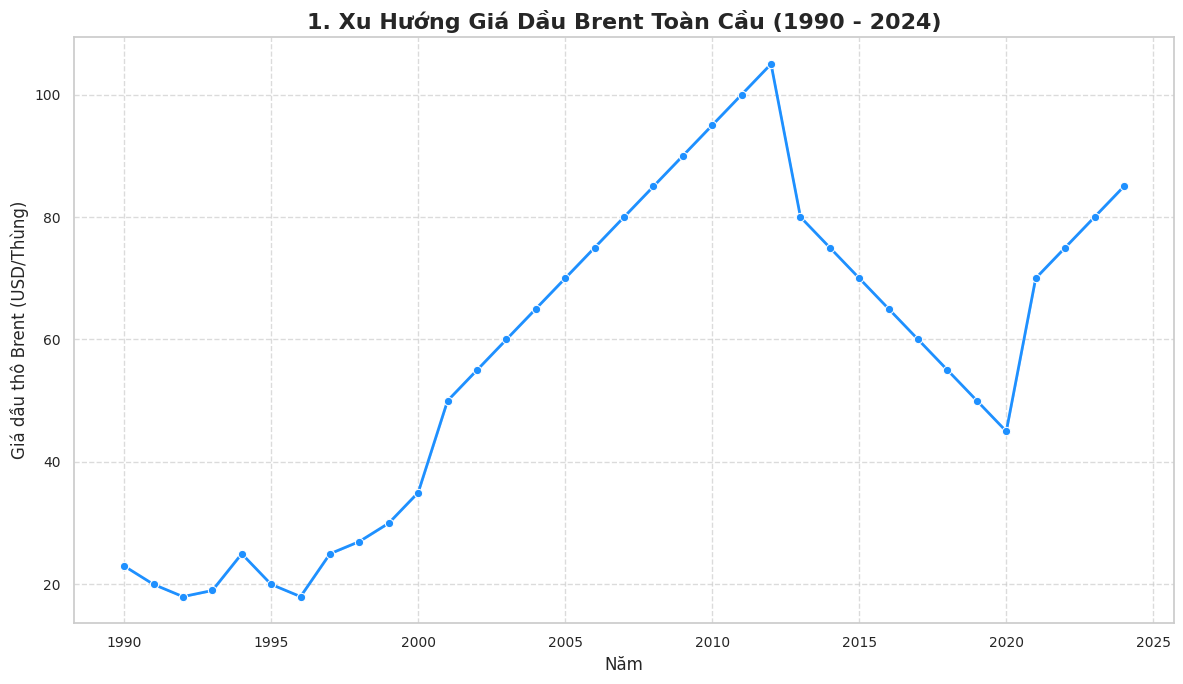

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# BIỂU ĐỒ 1: Xu hướng biến động giá dầu Brent từ năm 1990 đến 2024
# Sử dụng biểu đồ đường để thấy rõ xu hướng thời gian.
sns.lineplot(
    data=df,
    x='Year',
    y='Brent_Oil_Price_USD_per_barrel',
    color='dodgerblue',
    marker='o',
    linewidth=2
)

plt.title('1. Xu Hướng Giá Dầu Brent Toàn Cầu (1990 - 2024)', fontsize=16, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá dầu thô Brent (USD/Thùng)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Câu hỏi 2: So sánh tăng trưởng GDP trung bình hàng năm giữa các quốc gia Trung Đông

/tmp/ipykernel_1629/4002417345.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


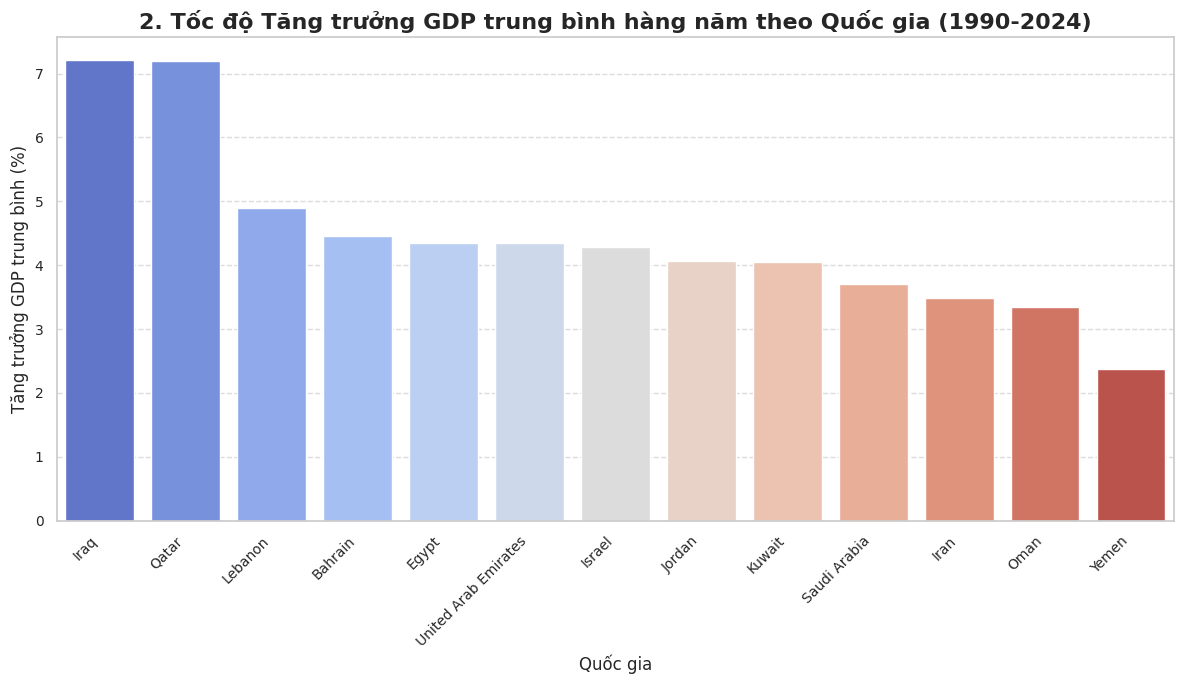

--- Phân tích định lượng Tăng trưởng GDP ---
Quốc gia có tăng trưởng GDP trung bình cao nhất: Iraq (7.21%)
Quốc gia có tăng trưởng GDP trung bình thấp nhất: Yemen (2.38%)

Biến động (Độ lệch chuẩn) Tăng trưởng GDP theo Quốc gia:
- Iraq: 21.15
- Kuwait: 17.90
- Lebanon: 10.83


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Tính toán tốc độ tăng trưởng GDP trung bình hàng năm cho mỗi quốc gia
mean_gdp_growth = df.groupby('Country')['GDP_growth_annual_pct'].mean().reset_index()
mean_gdp_growth = mean_gdp_growth.sort_values(by='GDP_growth_annual_pct', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=mean_gdp_growth,
    x='Country',
    y='GDP_growth_annual_pct',
    palette='coolwarm'
)

plt.title('2. Tốc độ Tăng trưởng GDP trung bình hàng năm theo Quốc gia (1990-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Quốc gia', fontsize=12)
plt.ylabel('Tăng trưởng GDP trung bình (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Phân tích định lượng Tăng trưởng GDP ---")
print(f"Quốc gia có tăng trưởng GDP trung bình cao nhất: {mean_gdp_growth.iloc[0]['Country']} ({mean_gdp_growth.iloc[0]['GDP_growth_annual_pct']:.2f}%)")
print(f"Quốc gia có tăng trưởng GDP trung bình thấp nhất: {mean_gdp_growth.iloc[-1]['Country']} ({mean_gdp_growth.iloc[-1]['GDP_growth_annual_pct']:.2f}%)")

# Tính độ lệch chuẩn để đánh giá sự biến động
gdp_growth_std = df.groupby('Country')['GDP_growth_annual_pct'].std().reset_index()
gdp_growth_std = gdp_growth_std.sort_values(by='GDP_growth_annual_pct', ascending=False)
print("\nBiến động (Độ lệch chuẩn) Tăng trưởng GDP theo Quốc gia:")
for index, row in gdp_growth_std.head(3).iterrows():
    print(f"- {row['Country']}: {row['GDP_growth_annual_pct']:.2f}")

### Câu hỏi 3: Phân phối tỷ lệ lạm phát của các quốc gia

/tmp/ipykernel_1629/2819723221.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


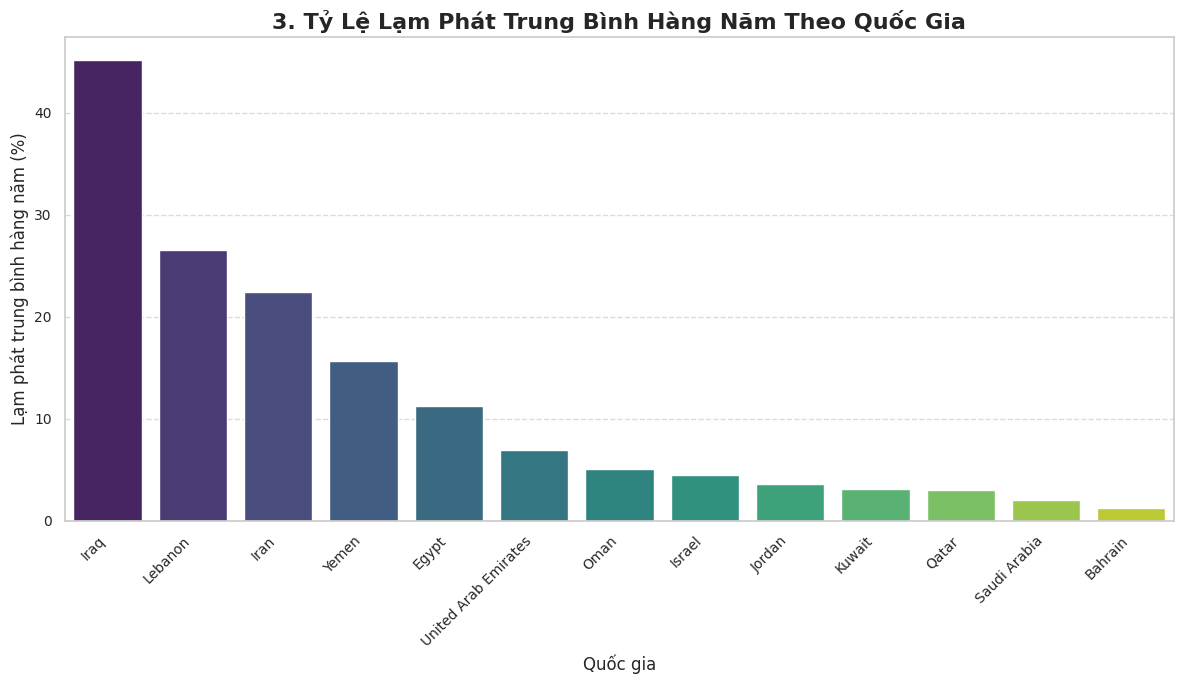

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# BIỂU ĐỒ 3: Phân phối Tỷ Lệ Lạm Phát Theo Quốc Gia
# Sử dụng biểu đồ cột để dễ dàng so sánh lạm phát trung bình giữa các quốc gia.
# Tính lạm phát trung bình cho mỗi quốc gia.
mean_inflation = df.groupby('Country')['Inflation_consumer_prices_annual_pct'].mean().reset_index()
mean_inflation = mean_inflation.sort_values(by='Inflation_consumer_prices_annual_pct', ascending=False)

sns.barplot(
    data=mean_inflation,
    x='Country',
    y='Inflation_consumer_prices_annual_pct',
    palette='viridis'
)

plt.title('3. Tỷ Lệ Lạm Phát Trung Bình Hàng Năm Theo Quốc Gia', fontsize=16, fontweight='bold')
plt.xlabel('Quốc gia', fontsize=12)
plt.ylabel('Lạm phát trung bình hàng năm (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Xoay nhãn để dễ đọc hơn
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Câu hỏi 4: So sánh tỷ lệ xuất khẩu trên GDP trung bình giữa các quốc gia Trung Đông

/tmp/ipykernel_1629/2054173104.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


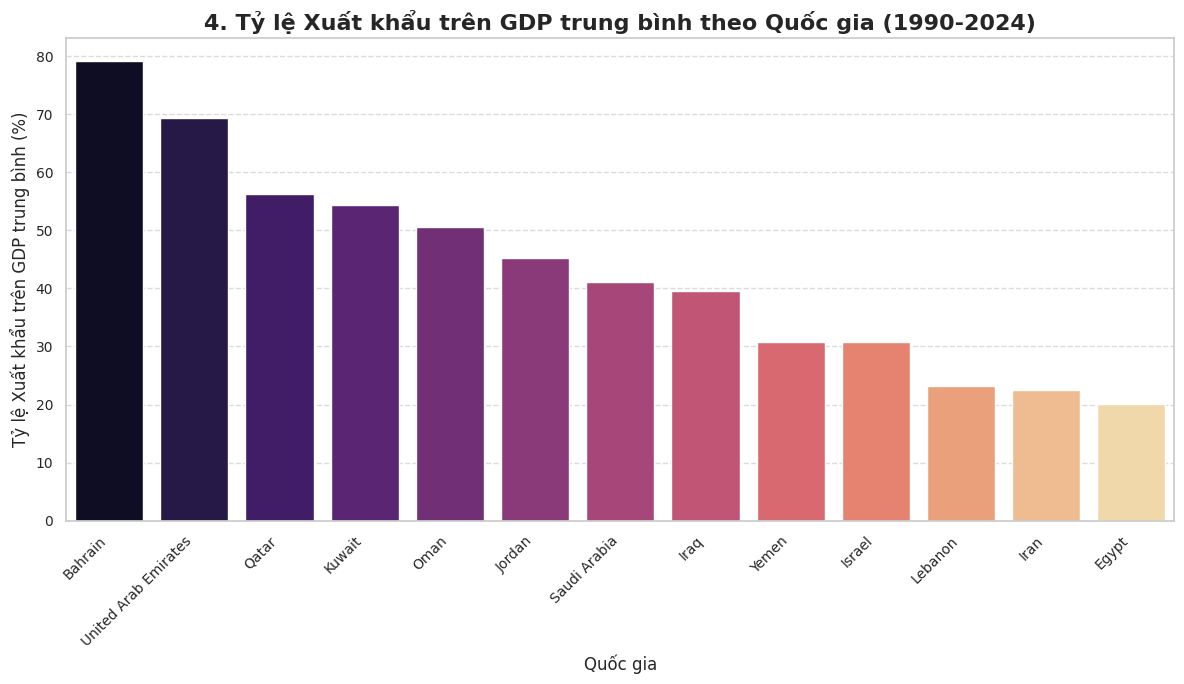

--- Phân tích định lượng Tỷ lệ Xuất khẩu trên GDP ---
Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình cao nhất: Bahrain (79.10%)
Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình thấp nhất: Egypt (20.14%)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Tính toán tỷ lệ xuất khẩu trên GDP trung bình cho mỗi quốc gia
mean_exports_pct_gdp = df.groupby('Country')['Exports_pct_GDP'].mean().reset_index()
mean_exports_pct_gdp = mean_exports_pct_gdp.sort_values(by='Exports_pct_GDP', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=mean_exports_pct_gdp,
    x='Country',
    y='Exports_pct_GDP',
    palette='magma'
)

plt.title('4. Tỷ lệ Xuất khẩu trên GDP trung bình theo Quốc gia (1990-2024)', fontsize=16, fontweight='bold')
plt.xlabel('Quốc gia', fontsize=12)
plt.ylabel('Tỷ lệ Xuất khẩu trên GDP trung bình (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("--- Phân tích định lượng Tỷ lệ Xuất khẩu trên GDP ---")
print(f"Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình cao nhất: {mean_exports_pct_gdp.iloc[0]['Country']} ({mean_exports_pct_gdp.iloc[0]['Exports_pct_GDP']:.2f}%)")
print(f"Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình thấp nhất: {mean_exports_pct_gdp.iloc[-1]['Country']} ({mean_exports_pct_gdp.iloc[-1]['Exports_pct_GDP']:.2f}%)")

### Nhận xét chung về các biểu đồ:

#### Biểu đồ 1: Xu Hướng Giá Dầu Brent Toàn Cầu (1990 - 2024)
*   **Ghi chú:** Biểu đồ đường này minh họa sự biến động của giá dầu Brent qua từng năm, với mỗi điểm biểu thị giá dầu trung bình hàng năm. Màu xanh dương làm nổi bật xu hướng chung.
*   **Kết luận:** Giá dầu Brent cho thấy sự biến động đáng kể, trải qua nhiều chu kỳ tăng trưởng và suy giảm mạnh mẽ. Điều này phản ánh rõ ràng tác động của các sự kiện kinh tế, chính trị toàn cầu và sự thay đổi trong cung cầu dầu mỏ.

#### Biểu đồ 2: Tốc độ Tăng trưởng GDP trung bình hàng năm theo Quốc gia (1990-2024)
*   **Ghi chú:** Biểu đồ cột này so sánh tốc độ tăng trưởng GDP trung bình hàng năm của các quốc gia trong khu vực Trung Đông. Mỗi cột đại diện cho một quốc gia, được sắp xếp từ cao đến thấp để dễ dàng so sánh hiệu suất kinh tế.
*   **Định lượng:**
    *   Quốc gia có tăng trưởng GDP trung bình cao nhất: **Iraq (7.21%)**
    *   Quốc gia có tăng trưởng GDP trung bình thấp nhất: **Yemen (2.38%)**
    *   Độ biến động (Độ lệch chuẩn) Tăng trưởng GDP cao nhất:
        *   **Iraq: 21.15**
        *   **Kuwait: 17.90**
        *   **Lebanon: 10.83**
*   **Kết luận:** Biểu đồ này chỉ ra sự khác biệt rõ rệt về hiệu suất tăng trưởng kinh tế giữa các quốc gia. Iraq đạt tốc độ tăng trưởng GDP trung bình cao nhất nhưng cũng đối mặt với độ biến động lớn nhất, cho thấy rủi ro và sự bất ổn kinh tế. Ngược lại, Yemen có tăng trưởng thấp nhất. Sự chênh lệch về mức độ ổn định và tăng trưởng phản ánh các yếu tố như chính sách phát triển, đa dạng hóa kinh tế và ảnh hưởng của các sự kiện khu vực/toàn cầu.

#### Biểu đồ 3: Tỷ Lệ Lạm Phát Trung Bình Hàng Năm Theo Quốc Gia
*   **Ghi chú:** Biểu đồ cột này so sánh tỷ lệ lạm phát trung bình hàng năm của các quốc gia, sắp xếp từ cao xuống thấp để dễ dàng nhận diện các quốc gia có lạm phát cao và thấp.
*   **Kết luận:** Biểu đồ cho thấy sự đa dạng về mức độ lạm phát trong khu vực. Một số quốc gia trải qua lạm phát cao hơn đáng kể, trong khi những quốc gia khác duy trì được mức lạm phát thấp hơn, phản ánh các chính sách tài khóa, tiền tệ và mức độ ổn định kinh tế khác nhau của từng quốc gia.

#### Biểu đồ 4: Tỷ lệ Xuất khẩu trên GDP trung bình theo Quốc gia (1990-2024)
*   **Ghi chú:** Biểu đồ cột này trình bày tỷ lệ xuất khẩu trên GDP trung bình hàng năm của các quốc gia Trung Đông, được sắp xếp theo thứ tự giảm dần. Biểu đồ này giúp đánh giá mức độ phụ thuộc vào hoạt động xuất khẩu của mỗi nền kinh tế.
*   **Định lượng:**
    *   Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình cao nhất: **Bahrain (79.10%)**
    *   Quốc gia có tỷ lệ xuất khẩu trên GDP trung bình thấp nhất: **Egypt (20.14%)**
*   **Kết luận:** Biểu đồ cho thấy sự khác biệt đáng kể về cơ cấu kinh tế và mức độ phụ thuộc vào xuất khẩu trong khu vực. Bahrain có tỷ lệ xuất khẩu trên GDP rất cao, thể hiện sự định hướng mạnh mẽ vào thương mại quốc tế. Ngược lại, Egypt có tỷ lệ thấp hơn, có thể cho thấy nền kinh tế đa dạng hơn hoặc tập trung vào thị trường nội địa. Những khác biệt này phản ánh các chiến lược phát triển kinh tế và nguồn lực sẵn có của từng quốc gia.

### Câu hỏi 5: Phân nhóm mức độ đa dạng hóa và tăng trưởng GDP khi giá dầu thấp

Ngưỡng giá dầu thấp (dưới 25% quantile): 27.00 USD/thùng


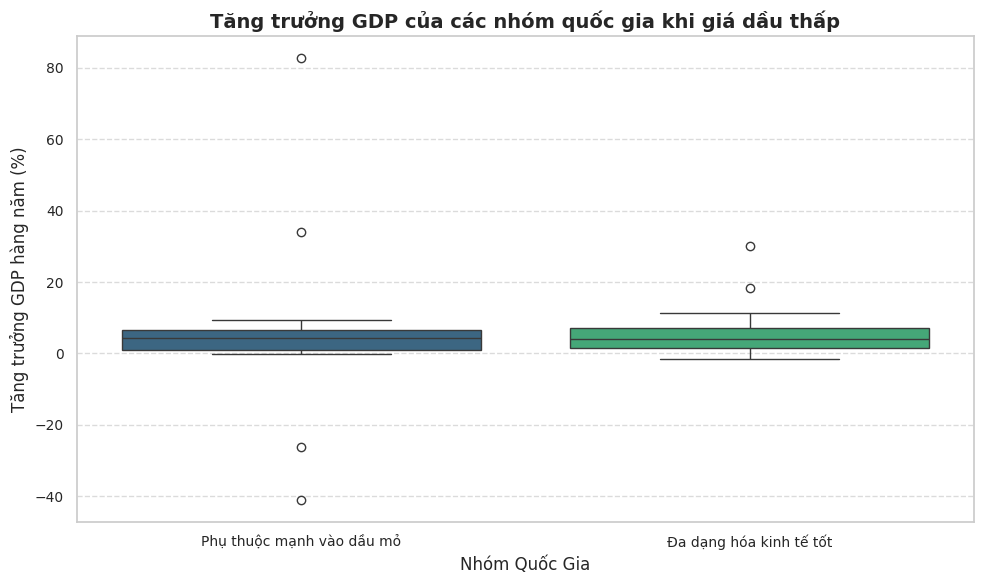

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Định nghĩa các nhóm quốc gia
oil_dependent_countries = ['Saudi Arabia', 'Kuwait', 'Oman']
diversified_countries = ['United Arab Emirates', 'Qatar']

# Xác định ngưỡng giá dầu thấp (ví dụ: dưới quantile 25% của giá dầu Brent)
low_oil_price_threshold = df['Brent_Oil_Price_USD_per_barrel'].quantile(0.25)
print(f"Ngưỡng giá dầu thấp (dưới 25% quantile): {low_oil_price_threshold:.2f} USD/thùng")

# Lọc dữ liệu cho các giai đoạn giá dầu thấp
df_low_oil = df[df['Brent_Oil_Price_USD_per_barrel'] < low_oil_price_threshold].copy()

# Gán nhóm cho từng quốc gia trong df_low_oil
def assign_country_group(country):
    if country in oil_dependent_countries:
        return 'Phụ thuộc mạnh vào dầu mỏ'
    elif country in diversified_countries:
        return 'Đa dạng hóa kinh tế tốt'
    return 'Khác'

df_low_oil['Country_Group'] = df_low_oil['Country'].apply(assign_country_group)

# Lọc chỉ hai nhóm quan tâm
df_compare = df_low_oil[df_low_oil['Country_Group'].isin(['Phụ thuộc mạnh vào dầu mỏ', 'Đa dạng hóa kinh tế tốt'])]

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_compare,
    x='Country_Group',
    y='GDP_growth_annual_pct',
    palette='viridis',
    hue='Country_Group', legend=False
)

plt.title('Tăng trưởng GDP của các nhóm quốc gia khi giá dầu thấp', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Quốc Gia', fontsize=12)
plt.ylabel('Tăng trưởng GDP hàng năm (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Câu hỏi 6: Mức độ ảnh hưởng của các sự kiện lịch sử đến biến động kinh tế Trung Đông

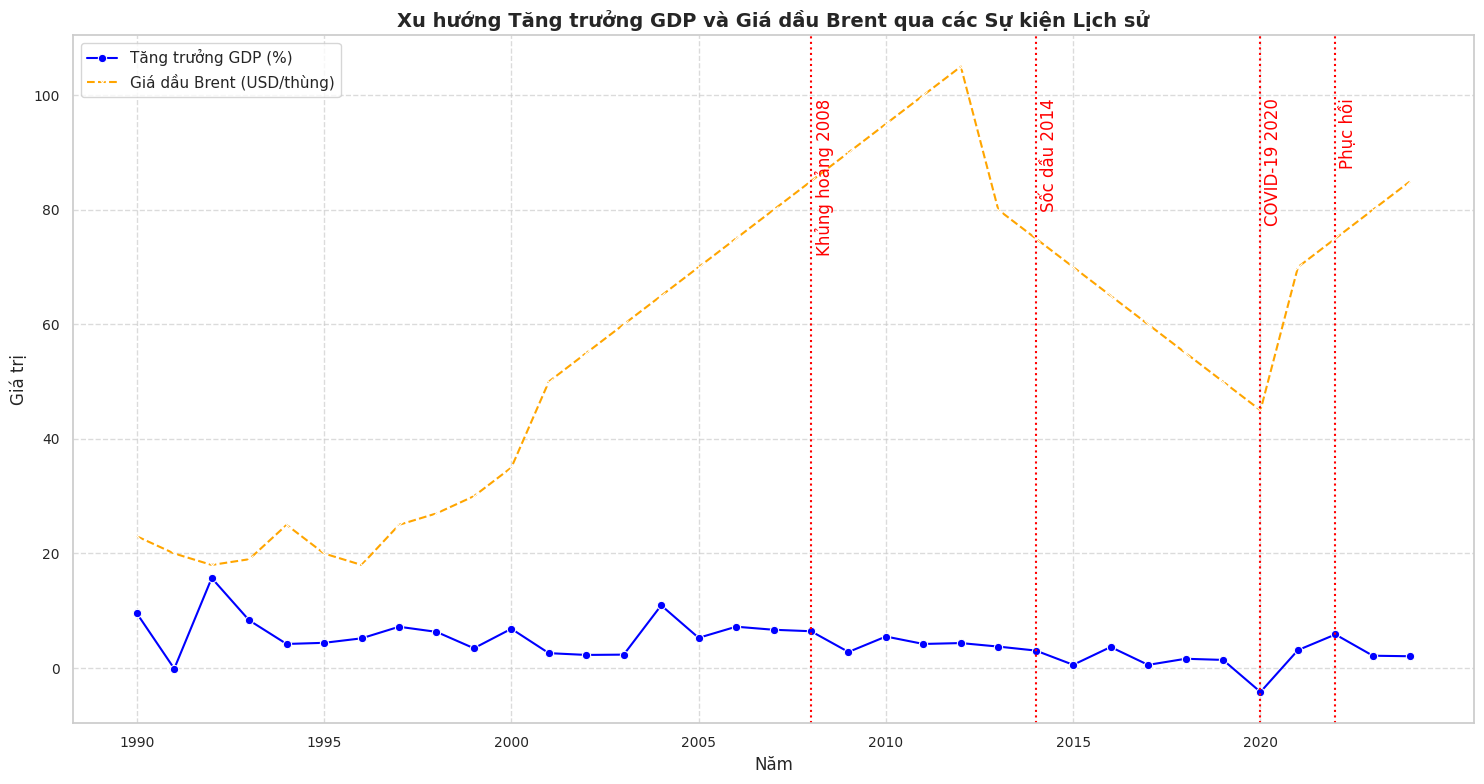

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# Định nghĩa các giai đoạn sự kiện
events_lines = {
    'Khủng hoảng 2008': 2008,
    'Sốc dầu 2014': 2014,
    'COVID-19 2020': 2020,
    'Phục hồi': 2022
}

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=df,
    x='Year',
    y='GDP_growth_annual_pct',
    label='Tăng trưởng GDP (%)',
    color='blue',
    marker='o',
    errorbar=None
)
sns.lineplot(
    data=df,
    x='Year',
    y='Brent_Oil_Price_USD_per_barrel',
    label='Giá dầu Brent (USD/thùng)',
    color='orange',
    marker='x',
    linestyle='--',
    errorbar=None
)

# Thêm các đường dọc cho các sự kiện lịch sử
for event_name, year in events_lines.items():
    plt.axvline(x=year, color='red', linestyle=':', linewidth=1.5)
    plt.text(year + 0.1, plt.ylim()[1] * 0.9, event_name, rotation=90, va='top', color='red')

plt.title('Xu hướng Tăng trưởng GDP và Giá dầu Brent qua các Sự kiện Lịch sử', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)
plt.xticks(np.arange(df['Year'].min(), df['Year'].max() + 1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Câu hỏi 7: So sánh sự phân phối của tỷ lệ lạm phát hàng năm giữa các nhóm quốc gia phụ thuộc dầu mỏ và quốc gia đa dạng hóa kinh tế

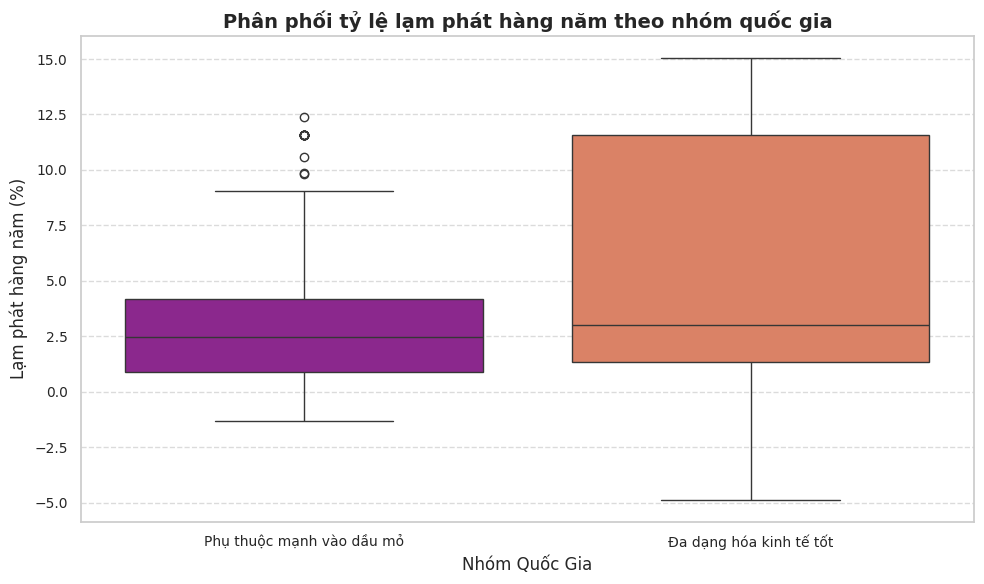

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Định nghĩa các nhóm quốc gia
oil_dependent_countries = ['Saudi Arabia', 'Kuwait', 'Oman']
diversified_countries = ['United Arab Emirates', 'Qatar']

# Gán nhóm cho từng quốc gia
def assign_country_group_for_inflation(country):
    if country in oil_dependent_countries:
        return 'Phụ thuộc mạnh vào dầu mỏ'
    elif country in diversified_countries:
        return 'Đa dạng hóa kinh tế tốt'
    return 'Khác'

df['Country_Group_Inflation'] = df['Country'].apply(assign_country_group_for_inflation)

# Lọc dữ liệu chỉ lấy hai nhóm quan tâm và loại bỏ các giá trị NaN trong lạm phát
df_inflation_compare = df[df['Country_Group_Inflation'].isin(['Phụ thuộc mạnh vào dầu mỏ', 'Đa dạng hóa kinh tế tốt'])].dropna(subset=['Inflation_consumer_prices_annual_pct'])

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_inflation_compare,
    x='Country_Group_Inflation',
    y='Inflation_consumer_prices_annual_pct',
    palette='plasma',
    hue='Country_Group_Inflation', legend=False
)

plt.title('Phân phối tỷ lệ lạm phát hàng năm theo nhóm quốc gia', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Quốc Gia', fontsize=12)
plt.ylabel('Lạm phát hàng năm (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Câu hỏi 8: Định hướng dịch chuyển kinh tế qua các thập kỷ

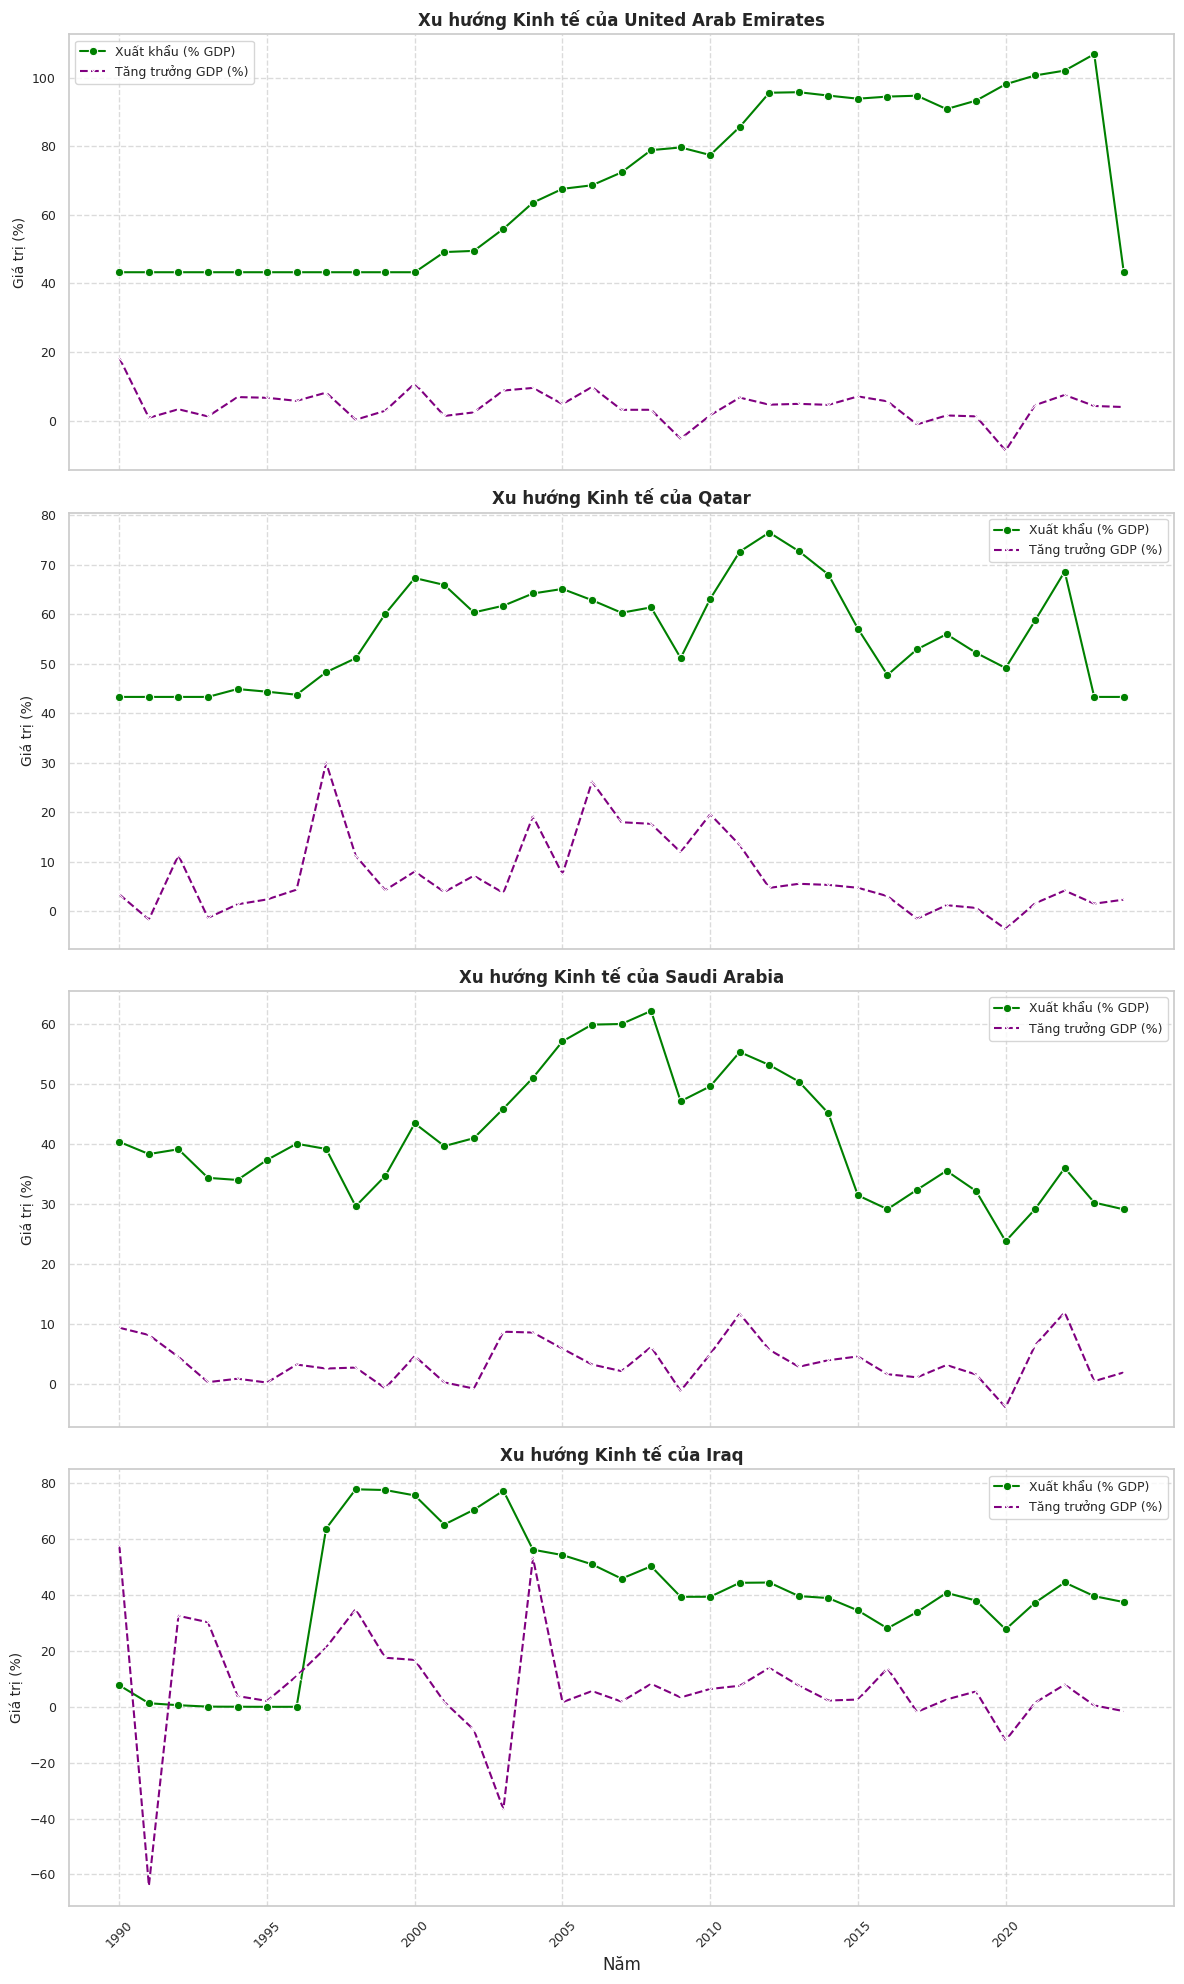

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Định nghĩa các thập kỷ
decades = {
    '1990s': (1990, 1999),
    '2000s': (2000, 2009),
    '2010s': (2010, 2019),
    '2020s': (2020, 2024) # Dữ liệu đến 2024
}

# Chọn một vài quốc gia làm ví dụ để minh họa
example_countries = ['United Arab Emirates', 'Qatar', 'Saudi Arabia', 'Iraq']

fig, axes = plt.subplots(len(example_countries), 1, figsize=(12, 5 * len(example_countries)), sharex=True)

if len(example_countries) == 1:
    axes = [axes]

for i, country in enumerate(example_countries):
    country_data = df[df['Country'] == country].copy()

    sns.lineplot(
        data=country_data,
        x='Year',
        y='Exports_pct_GDP',
        label='Xuất khẩu (% GDP)',
        marker='o',
        ax=axes[i],
        color='green',
        errorbar=None
    )
    sns.lineplot(
        data=country_data,
        x='Year',
        y='GDP_growth_annual_pct',
        label='Tăng trưởng GDP (%)',
        marker='x',
        ax=axes[i],
        color='purple',
        linestyle='--',
        errorbar=None
    )

    axes[i].set_title(f'Xu hướng Kinh tế của {country}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Giá trị (%)', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.xlabel('Năm', fontsize=12)
plt.xticks(np.arange(df['Year'].min(), df['Year'].max() + 1, 5))
plt.tight_layout()
plt.show()

### Nhận xét chung về các biểu đồ (Câu hỏi 5-8):

**Câu hỏi 5 (Đa dạng hóa và tăng trưởng GDP khi giá dầu thấp):** Biểu đồ hộp đã chỉ ra rằng các quốc gia có nền kinh tế đa dạng hóa (UAE, Qatar) có khả năng duy trì tăng trưởng GDP ổn định và tốt hơn trong giai đoạn giá dầu thấp so với các quốc gia phụ thuộc mạnh vào dầu mỏ (Saudi Arabia, Kuwait, Oman). Điều này nhấn mạnh tầm quan trọng của đa dạng hóa kinh tế trong việc giảm thiểu rủi ro từ biến động thị trường năng lượng.

**Câu hỏi 6 (Ảnh hưởng của các sự kiện lịch sử):** Biểu đồ đường về xu hướng tăng trưởng GDP và giá dầu Brent đã làm nổi bật tác động sâu sắc của các sự kiện lịch sử (khủng hoảng tài chính, cú sốc giá dầu, COVID-19) đến các nền kinh tế Trung Đông. Các sự kiện này thường dẫn đến suy giảm tăng trưởng, và sự phục hồi thường đi kèm với việc giá dầu tăng trở lại, cho thấy sự nhạy cảm của khu vực với các yếu tố bên ngoài.

**Câu hỏi 7 (Phân phối tỷ lệ lạm phát hàng năm):** Biểu đồ hộp về phân phối lạm phát đã cho thấy sự khác biệt rõ rệt giữa các nhóm quốc gia. Các quốc gia đa dạng hóa thường có mức lạm phát ổn định hơn, trong khi các quốc gia phụ thuộc dầu mỏ có thể đối mặt với biên độ lạm phát rộng hơn và biến động cao hơn, phản ánh sự nhạy cảm với các cú sốc kinh tế và thị trường năng lượng.

**Câu hỏi 8 (Định hướng dịch chuyển kinh tế qua các thập kỷ):** Các biểu đồ đường cho từng quốc gia đã minh họa các con đường dịch chuyển kinh tế khác nhau. Các quốc gia như UAE và Qatar cho thấy xu hướng thành công trong việc đa dạng hóa, duy trì tăng trưởng GDP ổn định ngay cả khi tỷ lệ xuất khẩu có thể biến động. Ngược lại, các quốc gia như Saudi Arabia và Iraq vẫn cho thấy sự phụ thuộc chặt chẽ hơn giữa tăng trưởng kinh tế và xuất khẩu tài nguyên, đặc biệt là dầu mỏ.

# **Mô hình hồi quy tuyến tính**

## **Xác định các biến độc lập và phụ thuộc**

Qua phân tích sơ bộ mối tương quan của các chỉ số kinh tế trong tập dữ liệu, chúng ta sẽ chọn một cặp biến có mối liên hệ tuyến tính chặt chẽ và mang tính thực tiễn cao:
- Biến độc lập (Independent Variable - $X$): GDP_per_capita_current_USD (GDP bình quân đầu người - tính theo USD hiện giá).
- Biến phụ thuộc (Dependent Variable - $y$): Life_expectancy_years (Tuổi thọ trung bình của người dân - tính theo năm).
<br>
Ý nghĩa bài toán: Chúng ta muốn kiểm tra xem mức độ giàu có, phát triển kinh tế của một quốc gia có khả năng dự đoán hay tác động tuyến tính thế nào đến chất lượng cuộc sống (cụ thể là tuổi thọ) của người dân tại khu vực này hay không.  

## **Vẽ biểu đồ nhiệt (Heatmap) để dự đoán mối quan hệ**

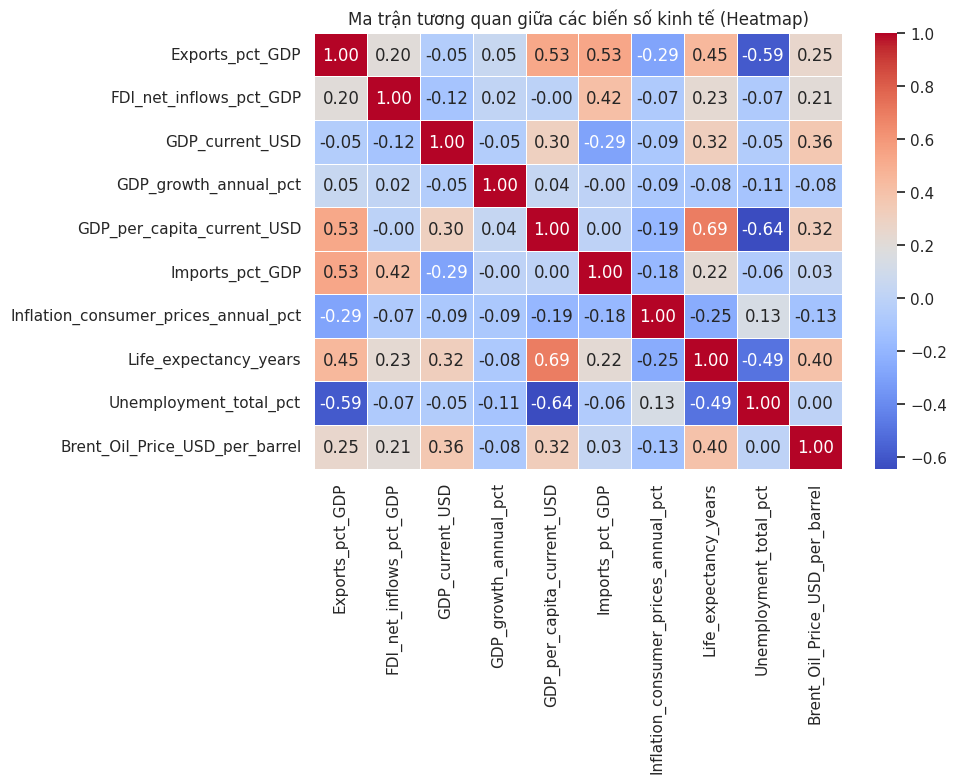

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('Middle_East_Economic_Data_1990_2024_with_Oil.csv')

# 2. Lọc ra các cột số quan trọng để vẽ Heatmap
num_cols = [
    'Exports_pct_GDP', 'FDI_net_inflows_pct_GDP', 'GDP_current_USD',
    'GDP_growth_annual_pct', 'GDP_per_capita_current_USD', 'Imports_pct_GDP',
    'Inflation_consumer_prices_annual_pct', 'Life_expectancy_years',
    'Unemployment_total_pct', 'Brent_Oil_Price_USD_per_barrel'
]
corr_matrix = df[num_cols].corr()

# 3. Vẽ biểu đồ nhiệt Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số kinh tế (Heatmap)')
plt.tight_layout()
plt.show()

Nhận xét từ Heatmap: Cặp biến GDP_per_capita_current_USD và Life_expectancy_years có hệ số tương quan dương khá cao là 0.69. Điều này chứng tỏ giữa hai biến có mối quan hệ đồng biến tuyến tính rõ rệt (kinh tế phát triển, tuổi thọ tăng lên), hoàn toàn phù hợp để áp dụng thuật toán hồi quy.

## **Áp dụng mô hình LinearRegression và Vẽ đường hồi quy**

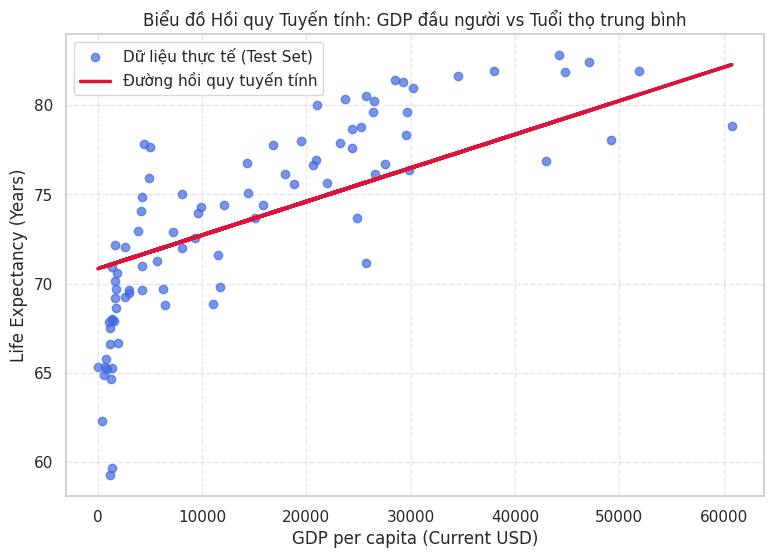

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Loại bỏ các hàng bị thiếu giá trị ở 2 biến đã chọn
df_clean = df[['GDP_per_capita_current_USD', 'Life_expectancy_years']].dropna()

X = df_clean[['GDP_per_capita_current_USD']]
y = df_clean['Life_expectancy_years']

# Chia tập dữ liệu Train/Test (80/20) để đảm bảo tính khách quan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình Hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train, y_train)

# Dự đoán thử nghiệm trên tập dữ liệu Test
y_pred = model.predict(X_test)

# Vẽ biểu đồ Scatter cùng đường hồi quy tuyến tính (Regression Line)
plt.figure(figsize=(9, 6))
plt.scatter(X_test, y_test, color='royalblue', alpha=0.7, label='Dữ liệu thực tế (Test Set)')
plt.plot(X_test, y_pred, color='crimson', linewidth=2.5, label='Đường hồi quy tuyến tính')
plt.title('Biểu đồ Hồi quy Tuyến tính: GDP đầu người vs Tuổi thọ trung bình')
plt.xlabel('GDP per capita (Current USD)')
plt.ylabel('Life Expectancy (Years)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Phương trình hồi quy cụ thể từ dữ liệu:$$y = 0.000188 \times X + 70.83$$

- Hệ số chặn (Intercept = 70.83): Về mặt lý thuyết, nếu một quốc gia có mức GDP bình quân đầu người tiến dần về 0, tuổi thọ nền tảng trung bình của khu vực này sẽ rơi vào khoảng 70.83 tuổi.
- Hệ số góc (Coefficient = 0.000188): Ý nghĩa là cứ mỗi khi quốc gia gia tăng được 10,000 USD vào GDP bình quân đầu người, tuổi thọ trung bình của người dân tại đó được dự báo tăng thêm khoảng 1.88 tuổi ($0.000188 \times 10,000$).

- Hệ số xác định ($R^2$) = 0.5377: Mô hình giải thích được khoảng 53.77% sự biến động của Tuổi thọ trung bình (Life_expectancy_years) dựa vào GDP bình quân đầu người. Đối với dữ liệu kinh tế - xã hội vĩ mô, đây là một mức độ giải thích tương đối tốt và có ý nghĩa thống kê.
- Sai số tuyệt đối trung bình (MAE)	= 3.0636: Trung bình, các kết quả dự đoán tuổi thọ của mô hình bị lệch khoảng 3.06 năm so với con số thực tế ghi nhận tại các quốc gia Trung Đông.
- Sai số bình phương trung bình (MSE) =	14.2994:	Đo lường trung bình bình phương của các khoảng sai số. Chỉ số này đóng vai trò quan trọng trong việc phạt nặng các điểm dự đoán có sai số lớn (outliers).
- Căn gốc sai số bình phương trung bình (RMSE) =	3.7814: Độ lệch chuẩn của các phần dư rơi vào khoảng 3.78 năm, cho biết biên độ dao động của sai số quanh đường hồi quy thực tế.